# Notebook 05 — Results Comparison & Analysis

Comprehensive visualization and cross-dataset comparison for the final report.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from visualization import plot_confusion_matrix, plot_pca_2d, plot_feature_importance
from feature_extractor import get_feature_domain, ALL_FEATURE_NAMES

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Results

In [2]:
xpqrs_summary = pd.read_csv('../results/tables/xpqrs_model_results.csv')
pq_summary = pd.read_csv('../results/tables/pq_model_results.csv')

print('XPQRS Results:')
display(xpqrs_summary)
print('\nPQ Disturbances Results:')
display(pq_summary)

rf_compare_path = '../results/tables/random_forest_baseline_vs_tuned.csv'
if os.path.exists(rf_compare_path):
    print('\nRandom Forest Baseline vs Tuned:')
    display(pd.read_csv(rf_compare_path))

XPQRS Results:


,Model,CV Accuracy,Test Accuracy,Test F1 (Macro),Test Precision,Test Recall
0,Random Forest (Tuned),0.8984 +/- 0.0033,0.9056,0.9049,0.9064,0.9056



PQ Disturbances Results:


,Model,CV Accuracy,Test Accuracy,Test F1 (Macro),Test Precision,Test Recall
0,Random Forest,0.9796 +/- 0.0154,0.9812,0.9816,0.9833,0.9816



Random Forest Baseline vs Tuned:


,Metric,Baseline,Tuned,Delta
0,Test Accuracy,0.9062,0.905588,-0.000612
1,Test F1 Macro,0.9056,0.904936,-0.000664
2,Test Precision Macro,NaN,0.906390,NaN
3,Test Recall Macro,NaN,0.905588,NaN
4,CV F1 Mean,NaN,0.897083,NaN
5,CV F1 Std,NaN,0.002955,NaN


## 2. Cross-Dataset Accuracy Comparison

,Model,XPQRS,PQ Disturbances


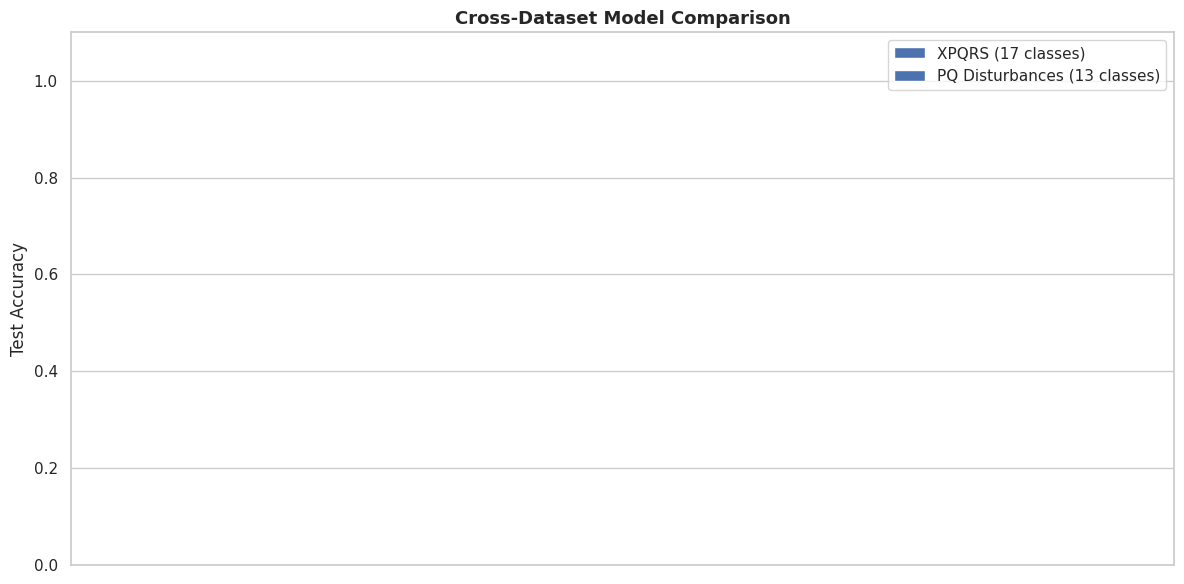

In [3]:
# Merge results for side-by-side comparison
xpqrs_acc = xpqrs_summary[['Model', 'Test Accuracy']].rename(columns={'Test Accuracy': 'XPQRS'})
pq_acc = pq_summary[['Model', 'Test Accuracy']].rename(columns={'Test Accuracy': 'PQ Disturbances'})
comparison = xpqrs_acc.merge(pq_acc, on='Model')

# Convert to float for plotting
comparison['XPQRS'] = comparison['XPQRS'].astype(float)
comparison['PQ Disturbances'] = comparison['PQ Disturbances'].astype(float)
comparison = comparison.sort_values('XPQRS', ascending=False)

display(comparison)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['XPQRS'], width, label='XPQRS (17 classes)', color='#2196F3')
bars2 = ax.bar(x + width/2, comparison['PQ Disturbances'], width, label='PQ Disturbances (13 classes)', color='#FF9800')

ax.set_ylabel('Test Accuracy')
ax.set_title('Cross-Dataset Model Comparison', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=20, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig('../results/figures/cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Class F1 Score Heatmap (XPQRS)

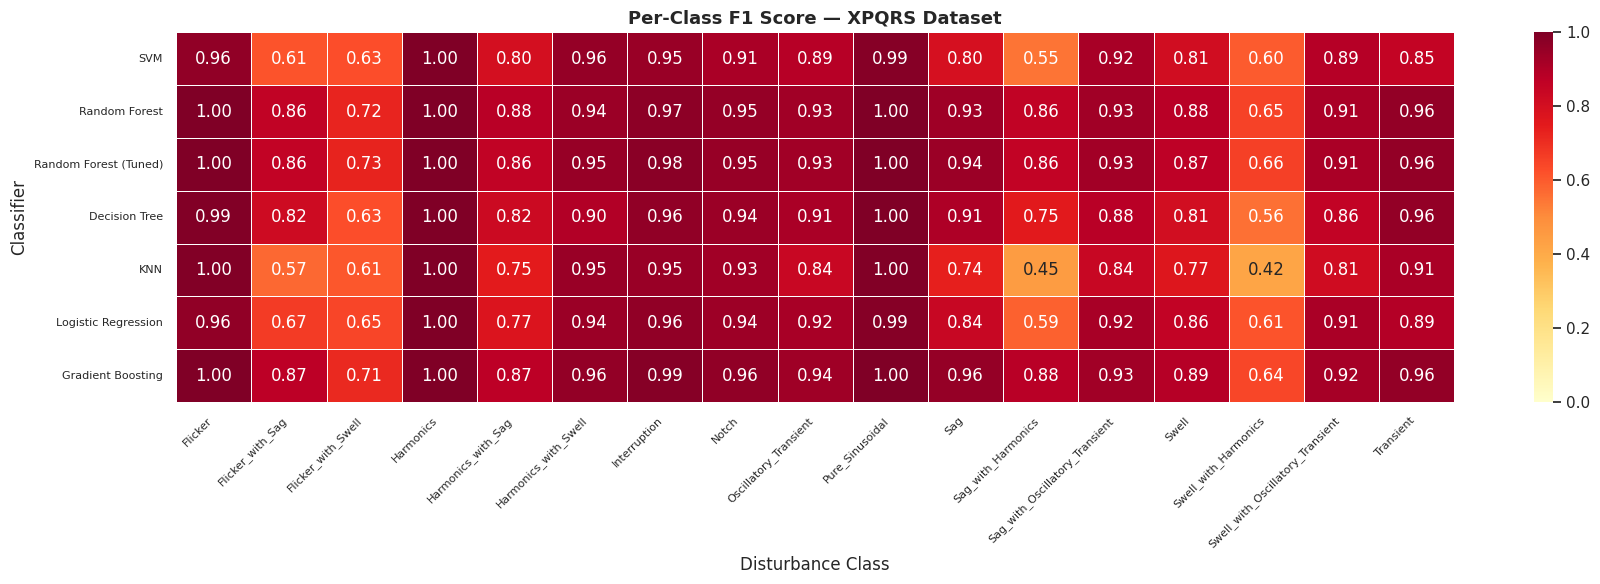

In [4]:
# Load features and re-run predictions to get per-class metrics
xpqrs_df = pd.read_csv('../results/tables/xpqrs_features.csv')
feature_cols = [c for c in xpqrs_df.columns if c != 'label']

le = LabelEncoder()
X = np.nan_to_num(xpqrs_df[feature_cols].values, nan=0.0, posinf=0.0, neginf=0.0)
y = le.fit_transform(xpqrs_df['label'])
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Load saved models and compute per-class F1
model_files = {
    'SVM': '../results/models/xpqrs_svm.pkl',
    'Random Forest': '../results/models/xpqrs_random_forest.pkl',
    'Random Forest (Tuned)': '../results/models/xpqrs_random_forest_tuned.pkl',
    'Decision Tree': '../results/models/xpqrs_decision_tree.pkl',
    'KNN': '../results/models/xpqrs_knn.pkl',
    'Logistic Regression': '../results/models/xpqrs_logistic_regression.pkl',
    'Gradient Boosting': '../results/models/xpqrs_gradient_boosting.pkl',
}

f1_rows = []
model_names = []
for model_name, model_file in model_files.items():
    if not os.path.exists(model_file):
        continue
    pipe = joblib.load(model_file)
    y_pred = pipe.predict(X_test)
    f1_rows.append(f1_score(y_test, y_pred, average=None))
    model_names.append(model_name)

f1_df = pd.DataFrame(f1_rows, index=model_names, columns=class_names)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(f1_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            vmin=0, vmax=1)
ax.set_title('Per-Class F1 Score — XPQRS Dataset', fontweight='bold', fontsize=13)
ax.set_ylabel('Classifier')
ax.set_xlabel('Disturbance Class')
ax.tick_params(labelsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig('../results/figures/xpqrs_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Importance Analysis

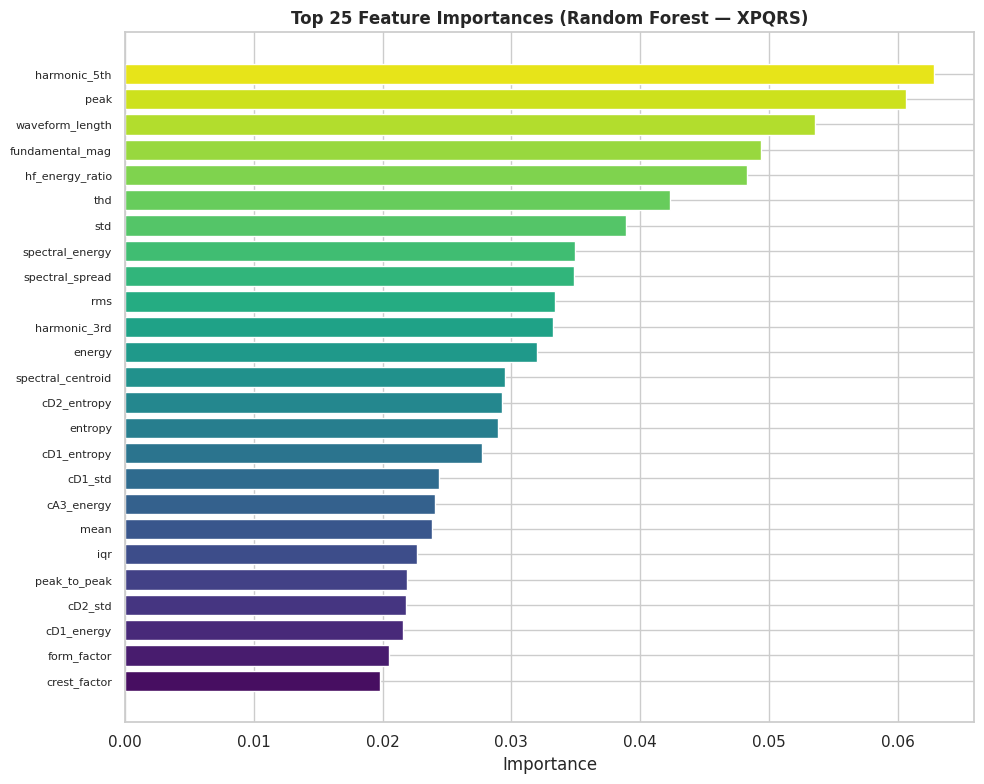

In [5]:
# Load Random Forest model for feature importance (prefer tuned if available)
rf_tuned_path = '../results/models/xpqrs_random_forest_tuned.pkl'
rf_base_path = '../results/models/xpqrs_random_forest.pkl'
rf_model_path = rf_tuned_path if os.path.exists(rf_tuned_path) else rf_base_path

rf_pipe = joblib.load(rf_model_path)
rf_model = rf_pipe.named_steps['clf']
importances = rf_model.feature_importances_

fig = plot_feature_importance(importances, feature_cols, top_n=25,
                              title='Top 25 Feature Importances (Random Forest — XPQRS)')
fig.savefig('../results/figures/final_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

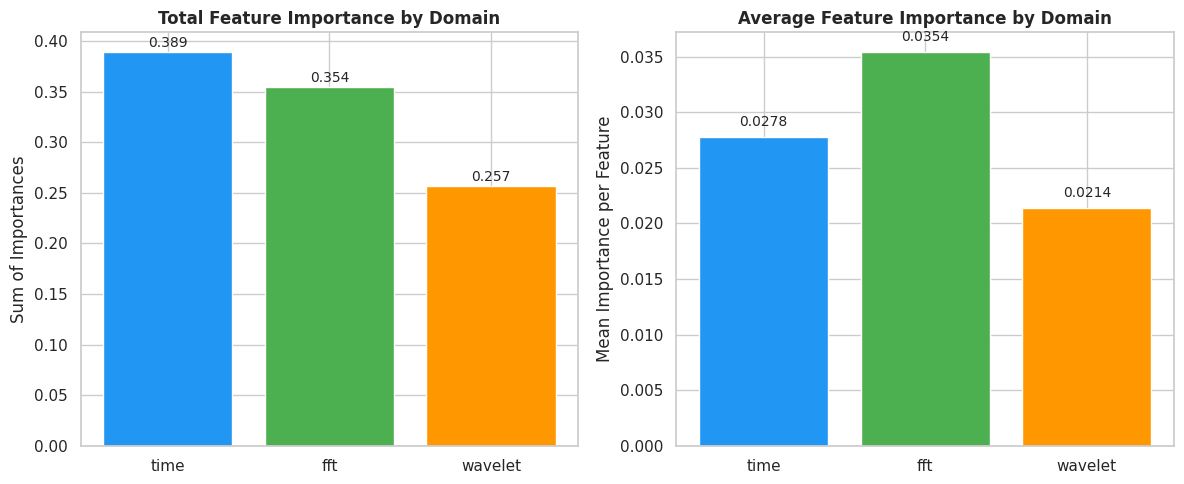

In [6]:
# Feature importance by domain
domain_importance = {'time': 0, 'fft': 0, 'wavelet': 0}
domain_counts = {'time': 0, 'fft': 0, 'wavelet': 0}

for feat, imp in zip(feature_cols, importances):
    domain = get_feature_domain(feat)
    if domain in domain_importance:
        domain_importance[domain] += imp
        domain_counts[domain] += 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total importance by domain
domains = list(domain_importance.keys())
totals = [domain_importance[d] for d in domains]
colors = ['#2196F3', '#4CAF50', '#FF9800']
axes[0].bar(domains, totals, color=colors)
axes[0].set_title('Total Feature Importance by Domain', fontweight='bold')
axes[0].set_ylabel('Sum of Importances')
for bar, val in zip(axes[0].patches, totals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10)

# Average importance by domain
averages = [domain_importance[d] / max(domain_counts[d], 1) for d in domains]
axes[1].bar(domains, averages, color=colors)
axes[1].set_title('Average Feature Importance by Domain', fontweight='bold')
axes[1].set_ylabel('Mean Importance per Feature')
for bar, val in zip(axes[1].patches, averages):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
fig.savefig('../results/figures/importance_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. t-SNE Visualization

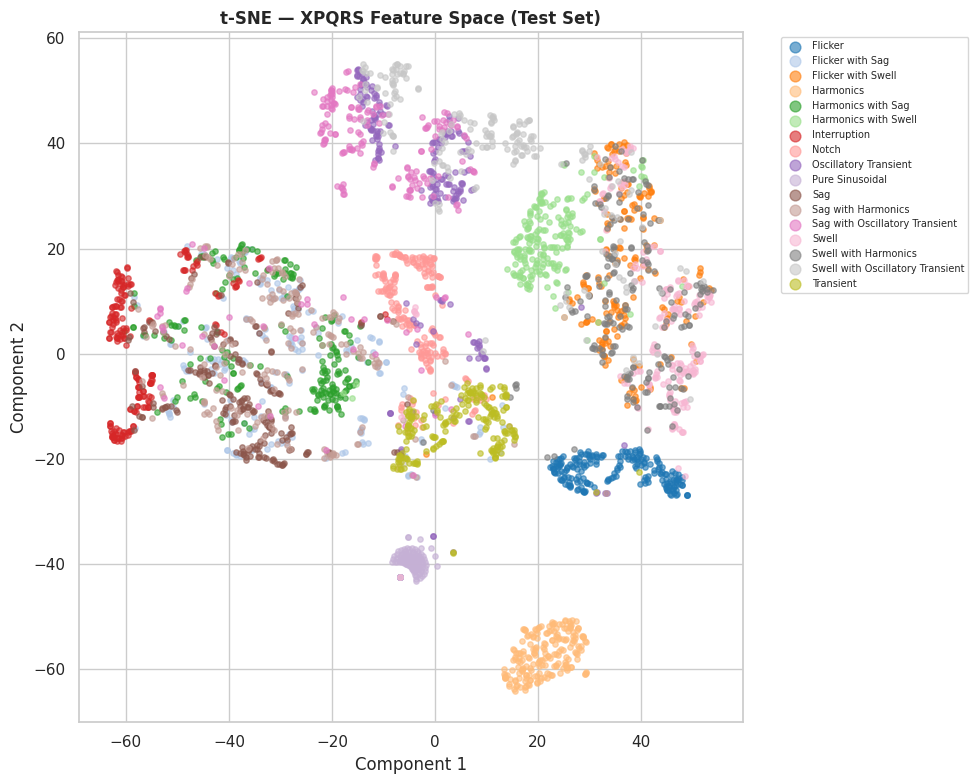

In [7]:
# t-SNE on test set (faster than full dataset)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_test_scaled)

test_labels = le.inverse_transform(y_test)
fig = plot_pca_2d(X_tsne, test_labels, sorted(class_names),
                  title='t-SNE — XPQRS Feature Space (Test Set)')
fig.savefig('../results/figures/tsne_xpqrs.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Misclassification Analysis

In [8]:
# Use the best model listed in summary
best_model_name = xpqrs_summary.iloc[0]['Model']
model_path_map = {
    'Random Forest': '../results/models/xpqrs_random_forest.pkl',
    'Random Forest (Tuned)': '../results/models/xpqrs_random_forest_tuned.pkl',
    'SVM': '../results/models/xpqrs_svm.pkl',
    'Decision Tree': '../results/models/xpqrs_decision_tree.pkl',
    'KNN': '../results/models/xpqrs_knn.pkl',
    'Logistic Regression': '../results/models/xpqrs_logistic_regression.pkl',
    'Gradient Boosting': '../results/models/xpqrs_gradient_boosting.pkl',
}

best_model_path = model_path_map.get(best_model_name)
if best_model_path is None or not os.path.exists(best_model_path):
    raise FileNotFoundError(f'Model path not found for {best_model_name}: {best_model_path}')

best_pipe = joblib.load(best_model_path)
y_pred_best = best_pipe.predict(X_test)

# Find misclassified samples
misclassified = y_test != y_pred_best
n_misclassified = misclassified.sum()
total = len(y_test)
print(f'Best model: {best_model_name}')
print(f'Misclassified: {n_misclassified}/{total} ({100*n_misclassified/total:.2f}%)')

# Most confused class pairs
cm = confusion_matrix(y_test, y_pred_best)
np.fill_diagonal(cm, 0)  # zero out diagonal

# Top 10 confused pairs
confused_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm[i, j] > 0:
            confused_pairs.append((class_names[i], class_names[j], cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)

print(f'\nTop 10 most confused class pairs:')
for true_cls, pred_cls, count in confused_pairs[:10]:
    print(f'  {true_cls:35s} -> {pred_cls:35s}  ({count} samples)')

Best model: Random Forest (Tuned)
Misclassified: 321/3400 (9.44%)

Top 10 most confused class pairs:
  Swell_with_Harmonics                -> Flicker_with_Swell                   (50 samples)
  Flicker_with_Swell                  -> Swell_with_Harmonics                 (25 samples)
  Flicker_with_Swell                  -> Swell                                (19 samples)
  Harmonics_with_Sag                  -> Sag_with_Harmonics                   (19 samples)
  Harmonics_with_Sag                  -> Flicker_with_Sag                     (17 samples)
  Swell_with_Harmonics                -> Swell                                (15 samples)
  Flicker_with_Sag                    -> Sag_with_Harmonics                   (12 samples)
  Sag_with_Oscillatory_Transient      -> Sag_with_Harmonics                   (12 samples)
  Swell_with_Oscillatory_Transient    -> Swell_with_Harmonics                 (12 samples)
  Flicker_with_Sag                    -> Harmonics_with_Sag                   (1

## 7. ROC Curves (Best Model, One-vs-Rest)

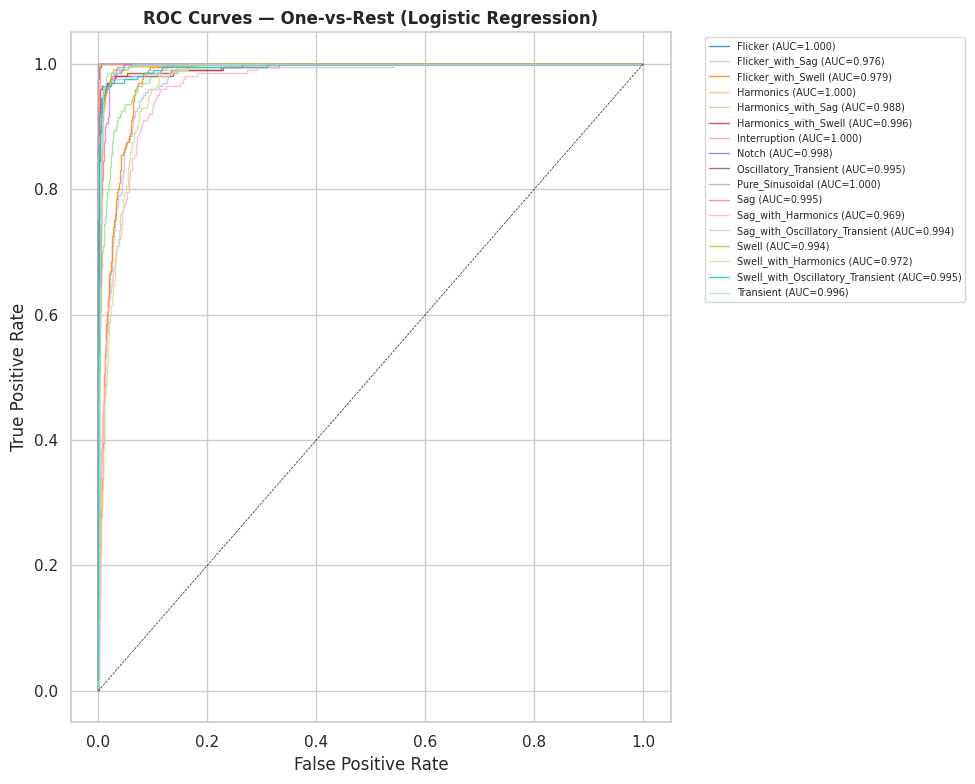

In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline

# Use Logistic Regression for probability estimates (needed for ROC curves)
from sklearn.linear_model import LogisticRegression

roc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, solver='lbfgs', max_iter=2000, random_state=42))
])
roc_pipe.fit(X_train, y_train)
y_prob = roc_pipe.predict_proba(X_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

# Plot ROC for all classes
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=1.0, alpha=0.8,
            label=f'{cls} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest (Logistic Regression)', fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
fig.savefig('../results/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Summary Table

In [10]:
# Combined summary for report
final_table = comparison.copy()

# Add F1 scores
xpqrs_f1 = xpqrs_summary[['Model', 'Test F1 (Macro)']].rename(columns={'Test F1 (Macro)': 'XPQRS F1'})
pq_f1 = pq_summary[['Model', 'Test F1 (Macro)']].rename(columns={'Test F1 (Macro)': 'PQ F1'})
final_table = final_table.merge(xpqrs_f1, on='Model').merge(pq_f1, on='Model')

final_table = final_table.rename(columns={'XPQRS': 'XPQRS Accuracy', 'PQ Disturbances': 'PQ Accuracy'})
final_table = final_table.sort_values('XPQRS Accuracy', ascending=False)

print('\n=== FINAL RESULTS SUMMARY ===')
print(f'XPQRS: 17 classes, 17000 signals, 36 extracted features')
print(f'PQ Disturbances: 13 classes, ~798 signals, 72 pre-extracted wavelet features')
print()
display(final_table)

final_table.to_csv('../results/tables/final_comparison.csv', index=False)
print('\nSaved to: results/tables/final_comparison.csv')


=== FINAL RESULTS SUMMARY ===
XPQRS: 17 classes, 17000 signals, 36 extracted features
PQ Disturbances: 13 classes, ~798 signals, 72 pre-extracted wavelet features



,Model,XPQRS Accuracy,PQ Accuracy,XPQRS F1,PQ F1



Saved to: results/tables/final_comparison.csv


## Key Findings

1. **Best performing classifier** on XPQRS dataset: (see table above)
2. **Feature domain contribution**: The relative importance of time-domain, FFT, and wavelet features
3. **Most confused classes**: Compound disturbances (e.g., Harmonics_with_Sag vs. Sag_with_Harmonics) are hardest to distinguish
4. **Cross-dataset comparison**: PQ Disturbances dataset has fewer samples but benefits from pre-extracted wavelet features
5. **Multi-domain feature extraction** (time + FFT + wavelet) provides comprehensive signal characterization for traditional ML classifiers